In [ ]:
import pandas as pd

df = pd.read_csv("application_train.csv")

In [ ]:
df = df.sample(10000, random_state=42)

In [ ]:
columns = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_FAM_MEMBERS",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

df = df[columns]

In [ ]:
df["TARGET"].value_counts()

,count
TARGET,
0,9177
1,823


In [ ]:
import numpy as np

# Age
df["Age"] = abs(df["DAYS_BIRTH"]) // 365

# Employment years
df["Employment_Years"] = abs(df["DAYS_EMPLOYED"]) // 365

# Income to Credit ratio
df["Income_Credit_Ratio"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"]

# EMI ratio
df["EMI_Ratio"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

In [ ]:
df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("TARGET", axis=1)
y = df["TARGET"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=200, learning_rate=0.1)

model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9265
[[1853    4]
 [ 143    0]]


In [ ]:
y_prob = model.predict_proba(x_test)[:,1]
print(y_prob[:10])

[0.01187504 0.06317165 0.01108721 0.08679415 0.07150967 0.07185793
 0.25395578 0.01631531 0.09451216 0.09952334]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(x_train, y_train)

y_pred_rf = model_rf.predict(x_test)

Handling Imbalanced Data with SMOTE

In [ ]:
# Install imbalanced-learn if not already installed
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

print(f'Original training set shape: {x_train.shape}, {y_train.shape}')
print(f'Resampled training set shape: {x_train_res.shape}, {y_train_res.shape}')
print('Class distribution after SMOTE:', y_train_res.value_counts())

Original training set shape: (8000, 32), (8000,)
Resampled training set shape: (14652, 32), (14652,)
Class distribution after SMOTE: TARGET
0    7326
1    7326
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

In [ ]:
import pandas as pd
print(pd.Series(y_train_sm).value_counts())

TARGET
0    7326
1    7326
Name: count, dtype: int64


In [ ]:
df["Risk_Score"] = df["AMT_CREDIT"] / (df["AMT_INCOME_TOTAL"] + 1)

In [ ]:
df["EMI_Burden"] = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + 1)

In [ ]:
y_train.value_counts()

,count
TARGET,
0,7326
1,674


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=600,        # increase trees
    max_depth=None,
    min_samples_split=5,     # prevent overfitting
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model_rf.fit(x_train_sm, y_train_sm)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=600, n_jobs=-1,
                       random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, roc_auc_score, confusion_matrix

print("Random Forest (Resampled) Accuracy:", accuracy_score(y_test, y_pred_rf_resampled))
print("Random Forest (Resampled) Precision:", precision_score(y_test, y_pred_rf_resampled))
print("Random Forest (Resampled) F1 Score:", f1_score(y_test, y_pred_rf_resampled))
print("Random Forest (Resampled) Recall:", recall_score(y_test, y_pred_rf_resampled))
print("Random Forest (Resampled) ROC AUC Score:", roc_auc_score(y_test, y_pred_rf_resampled))

print("\nConfusion Matrix (Resampled Random Forest Model):\n", confusion_matrix(y_test, y_pred_rf_resampled))

Random Forest (Resampled) Accuracy: 0.8975
Random Forest (Resampled) Precision: 0.07575757575757576
Random Forest (Resampled) F1 Score: 0.046511627906976744
Random Forest (Resampled) Recall: 0.03355704697986577
Random Forest (Resampled) ROC AUC Score: 0.500300943803277

Confusion Matrix (Resampled Random Forest Model):
 [[1790   61]
 [ 144    5]]


/tmp/ipykernel_1367/1702573261.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_resampled.head(20), palette='magma')


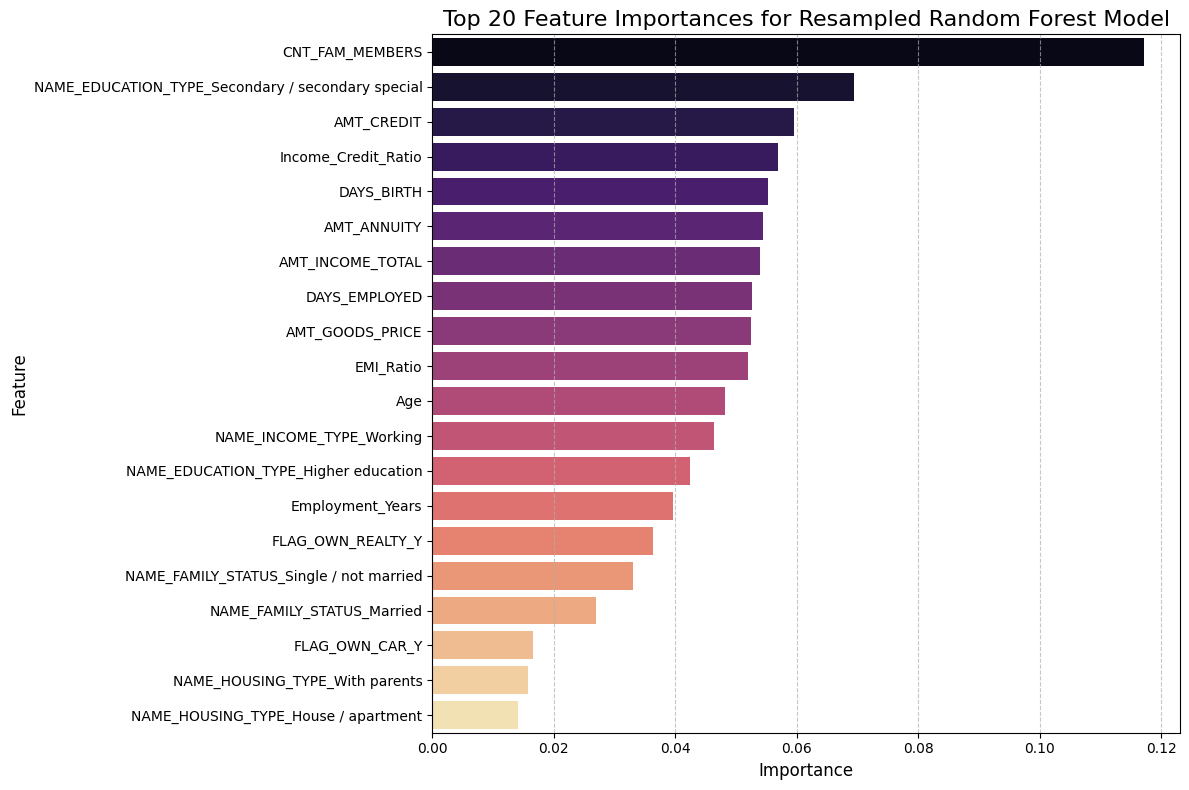

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the trained resampled Random Forest model
feature_importances_resampled = model_rf_resampled.feature_importances_

# Get feature names from the original X dataframe (or x_train before scaling)
# If x_train was scaled, X.columns is still the correct reference for feature names
feature_names_resampled = X.columns

# Create a DataFrame for better visualization
importance_df_resampled = pd.DataFrame({
    'Feature': feature_names_resampled,
    'Importance': feature_importances_resampled
})

# Sort features by importance
importance_df_resampled = importance_df_resampled.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_resampled.head(20), palette='magma')
plt.title('Top 20 Feature Importances for Resampled Random Forest Model', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

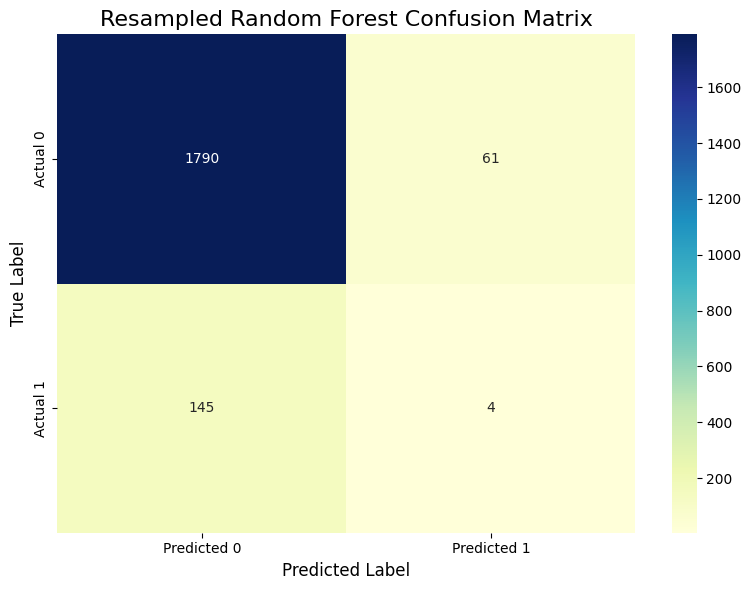

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the resampled Random Forest model
conf_matrix_resampled_rf = confusion_matrix(y_test, y_pred_rf_resampled)

# Create a heatmap for the Resampled Random Forest Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_resampled_rf, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Resampled Random Forest Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()